## Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Load the dataset

In [4]:
df = pd.read_csv('C:/Users/91700/OneDrive/Desktop/SARTHAK/Project UM/Datas/Drug_safety_and_pharmacovigilance.csv')

## Information Related to Data

In [6]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [7]:
df.shape

(200, 6)

In [8]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [10]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [11]:
df.corr(numeric_only = True)

,Age,Na_to_K
Age,1.000000,-0.063119
Na_to_K,-0.063119,1.000000


<Axes: >

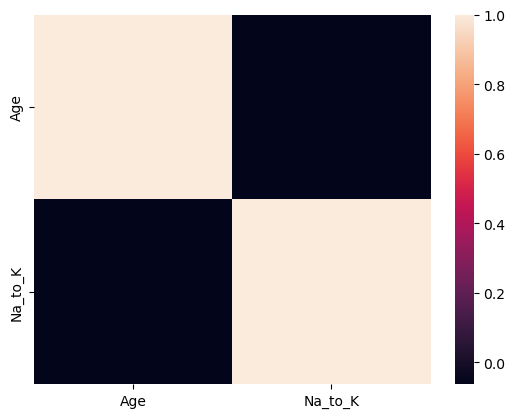

In [12]:
sns.heatmap(df.corr(numeric_only = True))

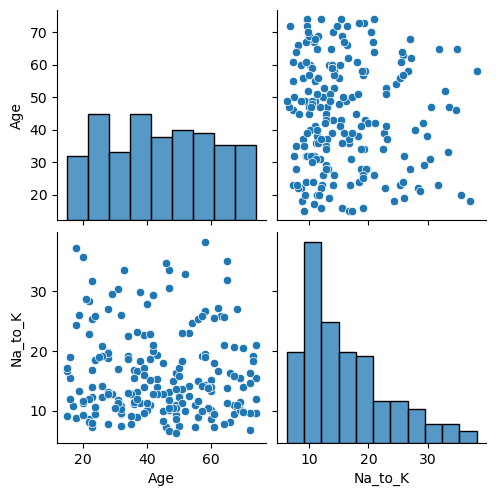

In [13]:
sns.pairplot(data=df)

In [14]:
df['Sex'].value_counts()

Sex
M    104
F     96
Name: count, dtype: int64

C:\Users\91700\AppData\Local\Temp\ipykernel_2168\3571803463.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette = 'bright')


<Axes: xlabel='Sex', ylabel='count'>

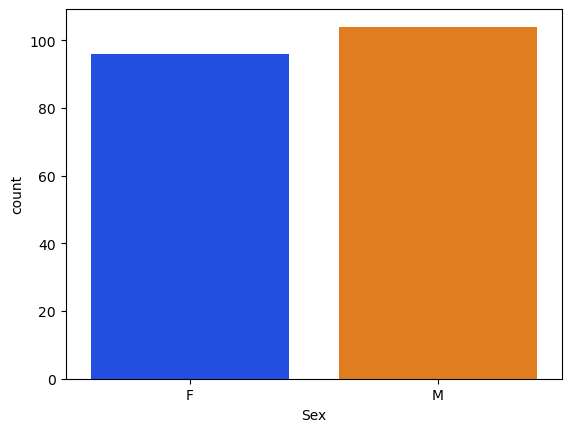

In [15]:
sns.countplot(x='Sex', data=df, palette = 'bright')

In [16]:
df['BP'].value_counts()

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

<Axes: xlabel='BP', ylabel='count'>

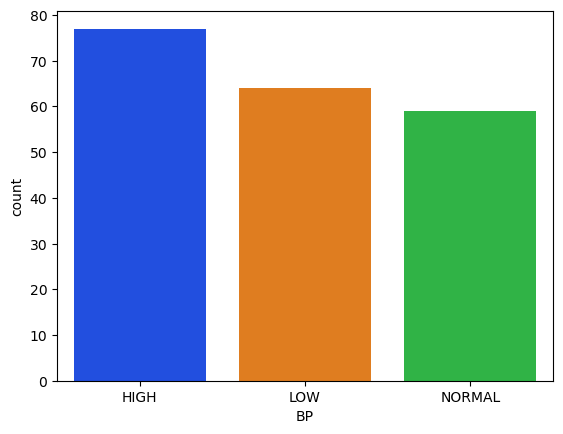

In [17]:
sns.countplot(x='BP', data=df, palette = 'bright', hue = 'BP')

In [18]:
df['Cholesterol'].value_counts()

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

<Axes: xlabel='Cholesterol', ylabel='count'>

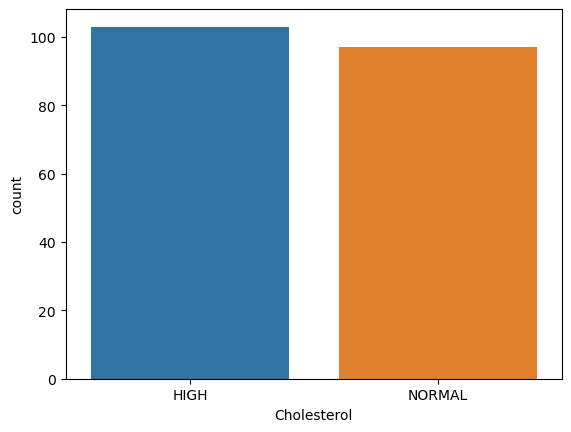

In [19]:
sns.countplot(x = 'Cholesterol', data=df, hue = 'Cholesterol')

In [20]:
df['Drug'].unique()

array(['DrugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

In [21]:
df['Drug'].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

<Axes: xlabel='Drug', ylabel='count'>

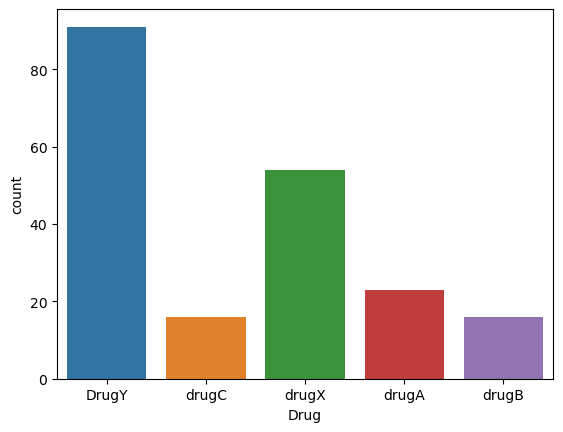

In [22]:
sns.countplot(x = 'Drug', data=df, hue = 'Drug')

## Data Preprocessing

In [24]:
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['BP'] = label_encoder.fit_transform(df['BP'])
df['Cholesterol'] = label_encoder.fit_transform(df['Cholesterol'])
df['Drug'] = label_encoder.fit_transform(df['Drug'])
# df.corr(numeric_only = True)

In [25]:
# sns.heatmap(df.corr(numeric_only = True))

## Define Fearture and Target

In [27]:
X = df.drop('Drug', axis = 1)
y= df['Drug']

In [28]:
X.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043


In [29]:
y.head()

0    0
1    3
2    3
3    4
4    0
Name: Drug, dtype: int32

## Split the data

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training and Evaluation

## LogisticRegression

In [34]:
# Model Training
lgr = LogisticRegression(random_state=36)
lgr.fit(X_train, y_train)

# Predictions
y_lgr = lgr.predict(X_test)

# Model Evaluation
print("Classification Report:")
print(classification_report(y_test, y_lgr))

Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        15
           1       1.00      0.50      0.67         6
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         5
           4       0.73      1.00      0.85        11

    accuracy                           0.80        40
   macro avg       0.70      0.70      0.68        40
weighted avg       0.72      0.80      0.74        40



D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [35]:
print("Confusion Matrix:")
confusion_matrix(y_test, y_lgr)

Confusion Matrix:


array([[15,  0,  0,  0,  0],
       [ 3,  3,  0,  0,  0],
       [ 0,  0,  3,  0,  0],
       [ 1,  0,  0,  0,  4],
       [ 0,  0,  0,  0, 11]], dtype=int64)

In [36]:
print("Accuracy Score:")
accuracy_score(y_test, y_lgr)

Accuracy Score:


0.8

## LinearDiscriminantAnalysis

In [39]:
# Model Training
ldr = LinearDiscriminantAnalysis()
ldr.fit(X_train, y_train)

# Predictions
y_ldr = ldr.predict(X_test)

# Model Evaluation
print("Classification Report:")
print(classification_report(y_test, y_ldr))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.86      1.00      0.92         6
           2       1.00      1.00      1.00         3
           3       1.00      0.20      0.33         5
           4       0.73      1.00      0.85        11

    accuracy                           0.88        40
   macro avg       0.92      0.83      0.81        40
weighted avg       0.91      0.88      0.85        40



In [40]:
print("Confusion Matrix:")
confusion_matrix(y_test, y_ldr)

Confusion Matrix:


array([[14,  1,  0,  0,  0],
       [ 0,  6,  0,  0,  0],
       [ 0,  0,  3,  0,  0],
       [ 0,  0,  0,  1,  4],
       [ 0,  0,  0,  0, 11]], dtype=int64)

In [41]:
print("Accuracy Score:")
accuracy_score(y_test, y_ldr)

Accuracy Score:


0.875

## KNeighborsClassifier

In [44]:
# Model Training
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_knn = knn.predict(X_test)

# Model Evaluation
print("Classification Report:")
print(classification_report(y_test, y_knn))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.60      0.50      0.55         6
           2       0.33      0.67      0.44         3
           3       1.00      0.20      0.33         5
           4       0.54      0.64      0.58        11

    accuracy                           0.70        40
   macro avg       0.69      0.60      0.58        40
weighted avg       0.76      0.70      0.69        40



In [45]:
print("Confusion Matrix:")
confusion_matrix(y_test, y_knn)

Confusion Matrix:


array([[15,  0,  0,  0,  0],
       [ 0,  3,  0,  0,  3],
       [ 0,  0,  2,  0,  1],
       [ 0,  1,  1,  1,  2],
       [ 0,  1,  3,  0,  7]], dtype=int64)

In [46]:
print("Accuracy Score:")
accuracy_score(y_test, y_knn)

Accuracy Score:


0.7

## RandomForestClassifier

In [49]:
# Model Training
rfc = RandomForestClassifier(random_state=36)
rfc.fit(X_train, y_train)

# Predictions
y_rfc = rfc.predict(X_test)

# Model Evaluation
print("Classification Report:")
print(classification_report(y_test, y_rfc))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [50]:
print("Confusion Matrix:")
confusion_matrix(y_test, y_rfc)

Confusion Matrix:


array([[15,  0,  0,  0,  0],
       [ 0,  6,  0,  0,  0],
       [ 0,  0,  3,  0,  0],
       [ 0,  0,  0,  5,  0],
       [ 0,  0,  0,  0, 11]], dtype=int64)

In [51]:
print("Accuracy Score:")
accuracy_score(y_test, y_rfc)

Accuracy Score:


1.0

## BaggingClassifier

In [54]:
# Model Training
bgc = BaggingClassifier(random_state=36)
bgc.fit(X_train, y_train)

# Predictions
y_bgc = bgc.predict(X_test)

# Model Evaluation
print("Classification Report:")
print(classification_report(y_test, y_bgc))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [55]:
print("Confusion Matrix:")
confusion_matrix(y_test, y_bgc)

Confusion Matrix:


array([[15,  0,  0,  0,  0],
       [ 0,  6,  0,  0,  0],
       [ 0,  0,  3,  0,  0],
       [ 0,  0,  0,  5,  0],
       [ 0,  0,  0,  0, 11]], dtype=int64)

In [56]:
print("Accuracy Score:")
accuracy_score(y_test, y_bgc)

Accuracy Score:


1.0

## GradientBoostingClassifier

In [59]:
# Model Training
gbc = GradientBoostingClassifier(random_state=36)
gbc.fit(X_train, y_train)

# Predictions
y_gbc = gbc.predict(X_test)

# Model Evaluation
print("Classification Report:")
print(classification_report(y_test, y_gbc))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [60]:
print("Confusion Matrix:")
confusion_matrix(y_test, y_gbc)

Confusion Matrix:


array([[15,  0,  0,  0,  0],
       [ 0,  6,  0,  0,  0],
       [ 0,  0,  3,  0,  0],
       [ 0,  0,  0,  5,  0],
       [ 0,  0,  0,  0, 11]], dtype=int64)

In [61]:
print("Accuracy Score:")
accuracy_score(y_test, y_gbc)

Accuracy Score:


1.0

## AdaBoostClassifier

In [64]:
# Model Training
abc = AdaBoostClassifier(random_state=36)
abc.fit(X_train, y_train)

# Predictions
y_abc = abc.predict(X_test)

# Model Evaluation
print("Classification Report:")
print(classification_report(y_test, y_abc))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.67      1.00      0.80         6
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         5
           4       0.69      1.00      0.81        11

    accuracy                           0.80        40
   macro avg       0.47      0.60      0.52        40
weighted avg       0.66      0.80      0.72        40



D:\Anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels w

In [65]:
print("Confusion Matrix:")
confusion_matrix(y_test, y_abc)

Confusion Matrix:


array([[15,  0,  0,  0,  0],
       [ 0,  6,  0,  0,  0],
       [ 0,  3,  0,  0,  0],
       [ 0,  0,  0,  0,  5],
       [ 0,  0,  0,  0, 11]], dtype=int64)

In [66]:
print("Accuracy Score:")
accuracy_score(y_test, y_abc)

Accuracy Score:


0.8

## Decision Tree Classifier

In [69]:
# Model Training
dtc = AdaBoostClassifier(random_state=36)
dtc.fit(X_train, y_train)

# Predictions
y_dtc = dtc.predict(X_test)

# Model Evaluation
print("Classification Report:")
print(classification_report(y_test, y_dtc))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.67      1.00      0.80         6
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         5
           4       0.69      1.00      0.81        11

    accuracy                           0.80        40
   macro avg       0.47      0.60      0.52        40
weighted avg       0.66      0.80      0.72        40



D:\Anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels w

In [70]:
print("Confusion Matrix:")
confusion_matrix(y_test, y_dtc)

Confusion Matrix:


array([[15,  0,  0,  0,  0],
       [ 0,  6,  0,  0,  0],
       [ 0,  3,  0,  0,  0],
       [ 0,  0,  0,  0,  5],
       [ 0,  0,  0,  0, 11]], dtype=int64)

In [71]:
print("Accuracy Score:")
accuracy_score(y_test, y_dtc)

Accuracy Score:


0.8